Final - neuralt netværk

In [2]:
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
import importlib_resources
import matplotlib.pyplot as plt
import torch
from scipy import stats
from scipy.io import loadmat
from sklearn import model_selection
from dtuimldmtools import draw_neural_net, train_neural_net
import pandas as pd

In [3]:
# Load csv file with data
df = pd.read_csv('null-corrected.csv', index_col=0)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
df = pd.get_dummies(df, columns=['cp', 'thal', 'restecg', 'slope'], drop_first=True, dtype=float)
df

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,num,cp_2.0,cp_3.0,cp_4.0,thal_3.0,thal_6.0,thal_7.0,restecg_1.0,restecg_2.0,slope_2.0,slope_3.0
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,2,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,110.0,264.0,0.0,132.0,0.0,1.2,0.0,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
299,68.0,1.0,144.0,193.0,1.0,141.0,0.0,3.4,2.0,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
300,57.0,1.0,130.0,131.0,0.0,115.0,1.0,1.2,1.0,3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
301,57.0,0.0,130.0,236.0,0.0,174.0,0.0,0.0,1.0,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


In [5]:
X = df.to_numpy()
y = df['num'].to_numpy() 
X

array([[ 63.,   1., 145., ...,   1.,   0.,   1.],
       [ 67.,   1., 160., ...,   1.,   1.,   0.],
       [ 67.,   1., 120., ...,   1.,   1.,   0.],
       ...,
       [ 57.,   1., 130., ...,   0.,   1.,   0.],
       [ 57.,   0., 130., ...,   1.,   1.,   0.],
       [ 38.,   1., 138., ...,   0.,   0.,   0.]], shape=(303, 20))

In [6]:
# Standardisering af data - træk middelværdi fra og divider med standardafvigelse
N = len(X)
X_ = X - np.ones((N, 1)) * X.mean(axis=0)
X_scaled = X_ / X.std(axis=0)
N, M = X_scaled.shape
X_scaled

array([[ 0.94872647,  0.68620244,  0.75752504, ...,  1.02337544,
        -0.92676626,  3.66450153],
       [ 1.39200191,  0.68620244,  1.61121989, ...,  1.02337544,
         1.07902072, -0.27288841],
       [ 1.39200191,  0.68620244, -0.6652997 , ...,  1.02337544,
         1.07902072, -0.27288841],
       ...,
       [ 0.28381332,  0.68620244, -0.0961698 , ..., -0.97715849,
         1.07902072, -0.27288841],
       [ 0.28381332, -1.4572959 , -0.0961698 , ...,  1.02337544,
         1.07902072, -0.27288841],
       [-1.82174501,  0.68620244,  0.35913411, ..., -0.97715849,
        -0.92676626, -0.27288841]], shape=(303, 20))

In [7]:
# Standardisering af data - træk middelværdi fra og divider med standardafvigelse
N = len(y)
Y_ = y - np.ones((N, 1)) * y.mean(axis=0)
Y_scaled = Y_ / y.std(axis=0)
N, M = Y_scaled.shape
Y_scaled

array([[-0.76419779,  0.86644961,  0.05112591, ...,  1.68177331,
         0.05112591, -0.76419779],
       [-0.76419779,  0.86644961,  0.05112591, ...,  1.68177331,
         0.05112591, -0.76419779],
       [-0.76419779,  0.86644961,  0.05112591, ...,  1.68177331,
         0.05112591, -0.76419779],
       ...,
       [-0.76419779,  0.86644961,  0.05112591, ...,  1.68177331,
         0.05112591, -0.76419779],
       [-0.76419779,  0.86644961,  0.05112591, ...,  1.68177331,
         0.05112591, -0.76419779],
       [-0.76419779,  0.86644961,  0.05112591, ...,  1.68177331,
         0.05112591, -0.76419779]], shape=(303, 303))

In [8]:
attributeNames = list(df.drop(columns='num').columns)
len(attributeNames)

19

Using device: cuda
tensor([[ 0.9487,  0.6862,  0.7575,  ...,  1.0234, -0.9268,  3.6645],
        [ 1.3920,  0.6862,  1.6112,  ...,  1.0234,  1.0790, -0.2729],
        [ 1.3920,  0.6862, -0.6653,  ...,  1.0234,  1.0790, -0.2729],
        ...,
        [ 0.2838,  0.6862, -0.0962,  ..., -0.9772,  1.0790, -0.2729],
        [ 0.2838, -1.4573, -0.0962,  ...,  1.0234,  1.0790, -0.2729],
        [-1.8217,  0.6862,  0.3591,  ..., -0.9772, -0.9268, -0.2729]],
       device='cuda:0')
tensor([[-0.7642,  0.8664,  0.0511,  ...,  1.6818,  0.0511, -0.7642],
        [-0.7642,  0.8664,  0.0511,  ...,  1.6818,  0.0511, -0.7642],
        [-0.7642,  0.8664,  0.0511,  ...,  1.6818,  0.0511, -0.7642],
        ...,
        [-0.7642,  0.8664,  0.0511,  ...,  1.6818,  0.0511, -0.7642],
        [-0.7642,  0.8664,  0.0511,  ...,  1.6818,  0.0511, -0.7642],
        [-0.7642,  0.8664,  0.0511,  ...,  1.6818,  0.0511, -0.7642]],
       device='cuda:0')

Outter crossvalidation fold: 2/10

Inner crossvalidation fold: 2

RuntimeError: mat1 and mat2 shapes cannot be multiplied (217x20 and 303x1)

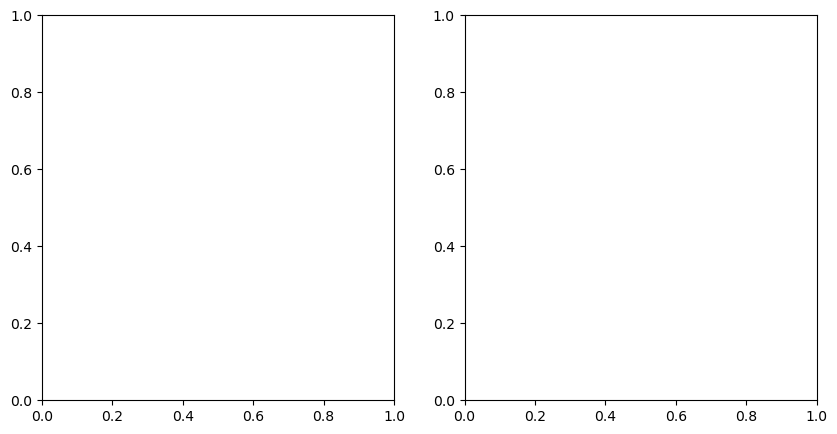

In [9]:
# Step 1: Set up outer cross-validation
K1 = 10  # outer folds
K2 = 5 # inner folds

CV_outer = KFold(n_splits=K1, shuffle=True, random_state=42)

# Define candidate values for number of hidden units
hidden_units_candidates = [1, 2, 4, 8, 16]

folds = list(CV_outer.split(X_scaled))

# Set device to CUDA if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Convert targets to tensor (as float for regression)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).squeeze().to(device)
Y_tensor = torch.tensor(Y_scaled, dtype=torch.float32).squeeze().to(device)
print(X_tensor)
print(Y_tensor)

max_iter = 100
n_replicates = 1   # number of networks trained in each k-fold. Gets passed in the model 

loss_fn = torch.nn.MSELoss()  # notice how this is now a mean-squared-error loss

# List storing gen_errors in each outer loop
ANN_errors = []  
n_hidden_layer_error = np.zeros((K1, len(hidden_units_candidates)))
best_n_hidden_neurons = []


# Setup figure for display of learning curves and error rates in fold
summaries, summaries_axes = plt.subplots(1, 2, figsize=(10, 5))
# Make a list for storing assigned color of learning curve for up to K=10
color_list = [
    "tab:orange",
    "tab:green",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan",
    "tab:red",
    "tab:blue",
]

# ANN

# outer loop
for outer_fold_idx, (outer_train_index, outer_test_index) in enumerate(folds, start=1):
    print("\nOutter crossvalidation fold: {0}/{1}".format(outer_fold_idx + 1, K1))
    X_train_outer_tensor, X_test_outer_tensor = X_tensor[outer_train_index], X_tensor[outer_test_index]
    Y_train_outer_tensor, Y_test_outer_tensor = Y_tensor[outer_train_index], Y_tensor[outer_test_index]

    CV_inner = KFold(n_splits=K2, shuffle=True, random_state=42)

    inner_folds = list(CV_inner.split(X_train_outer_tensor))

    for inner_fold_idx, (inner_train_index, validation_index) in enumerate(inner_folds, start=1):
        print("\nInner crossvalidation fold: {0}/{1}".format(inner_fold_idx + 1, K2))
        X_train_inner_tensor, X_validate_tensor = X_tensor[inner_train_index], X_tensor[validation_index]
        Y_train_inner_tensor, Y_validate_tensor = Y_tensor[inner_train_index], Y_tensor[validation_index]


        
        # Different number of hidden units in hidden layer 
        for n_hidden_neuron in hidden_units_candidates:
            print(f"{n_hidden_neuron} hidden layer")
            # Define the model
            model = lambda: torch.nn.Sequential(
            torch.nn.Linear(M, n_hidden_neuron),
            torch.nn.Tanh(),
            torch.nn.Linear(n_hidden_neuron, 1)
            ).to(device)

            # Train network on our the inner training data 
            net, final_loss, learning_curve = train_neural_net(     #network(net) is the trained neural network. Takes the 20 attribute as input and outputs its estimate of the heart disease
                model,
                loss_fn,
                X=X_train_inner_tensor,
                y=Y_train_inner_tensor,
                n_replicates=n_replicates,
                max_iter=max_iter,
            )


            # Determine estimated class labels for test set
            y_validate_estimate = net(X_validate_tensor)
        
            # Determine the test error for the specifik amount of hidden layers in the inner fold using MSE
            squared_error = (y_validate_estimate.float() - Y_validate_tensor.float()) ** 2  # squared error
            mse = (sum(squared_error).type(torch.float) / len(Y_validate_tensor)).mean() #.data.numpy()  # mean
            n_hidden_layer_error[outer_fold_idx,hidden_units_candidates.index(n_hidden_neuron)] += mse.item()/K1


    # ANN: Trains neural network on the test set in the  outer fold 
    # Uses the optimal number of hidden units/neurons found in the inner validation  
    n_hidden_neuron = hidden_units_candidates[np.argmin(n_hidden_layer_error[outer_fold_idx])] # finds the smallest error and uses the number of hidden units/neurons from there
    best_n_hidden_neurons.append(n_hidden_neuron) # adds to the list (to be printed in document)

    model = lambda: torch.nn.Sequential(
    torch.nn.Linear(M, n_hidden_neuron), 
    torch.nn.Tanh(),
    torch.nn.Linear(n_hidden_neuron, 1)
    ).to(device)

    # Train the net on training data
    net, final_loss, learning_curve = train_neural_net(   
        model,
        loss_fn,
        X=X_train_outer_tensor,
        y=Y_train_outer_tensor,
        n_replicates=n_replicates,
        max_iter=max_iter,
        )

    # Determine estimated class labels for test set. 
    y_test_estimate = net(X_test_outer_tensor)
        
    # Determine the test error using MSE for the fold 
    squared_error = (y_test_estimate.float() - Y_test_outer_tensor.float()) ** 2  # squared error
    mse = ((y_test_estimate.float() - Y_test_outer_tensor.float()) ** 2).mean()  #mse = (sum(squared_error).type(torch.float) / len(Y_test_outer_tensor)).data.numpy()  # mean
    ANN_errors.append(mse.item())

    # Display the learning curve for the best net in the current fold (learning curves)
    (h,) = summaries_axes[0].plot(learning_curve, color=color_list[outer_fold_idx])
    h.set_label("CV fold {0}".format(outer_fold_idx + 1))
    summaries_axes[0].set_xlabel("Iterations")
    summaries_axes[0].set_xlim((0, max_iter))
    summaries_axes[0].set_ylabel("Loss")
    summaries_axes[0].set_title("Learning curves")


print("ANN errors:",ANN_errors, "with respectively", best_n_hidden_neurons, "number of hidden layers")

#Neural Network Plots

# Display the MSE across folds (block diagram)
summaries_axes[1].bar(
    np.arange(1, K1 + 1), np.squeeze(np.asarray(ANN_errors)), color=color_list
)
summaries_axes[1].set_xlabel("Fold")
summaries_axes[1].set_xticks(np.arange(1, K1 + 1))
summaries_axes[1].set_ylabel("MSE")
summaries_axes[1].set_title("Test mean-squared-error")


# Netværk
print("Diagram of best neural net in last fold:")
weights = [net[i].weight.data.cpu().numpy().T for i in [0, 2]]
biases = [net[i].bias.data.cpu().numpy() for i in [0, 2]]
tf = [str(net[i]) for i in [1, 2]]
draw_neural_net(weights, biases, tf, attribute_names=attributeNames.tolist())
